Largura total: 19.10 mm
Altura total: 18.80 mm
Largura de cada terminal: 5.20 mm
Espessura fora do plano: 0.65 mm
Info    : Cannot bind existing OpenCASCADE surface 1 to second tag 2                                                            
Info    : Could not preserve tag of 2D object 2 (->1)
Info    : Cannot bind existing OpenCASCADE surface 1 to second tag 3
Info    : Could not preserve tag of 2D object 3 (->1)
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 5 (Line)
Info    : [ 10%] Meshing curve 6 (Line)
Info    : [ 20%] Meshing curve 7 (Line)
Info    : [ 30%] Meshing curve 8 (Line)
Info    : [ 40%] Meshing curve 9 (Line)
Info    : [ 50%] Meshing curve 10 (Line)
Info    : [ 60%] Meshing curve 11 (Line)
Info    : [ 60%] Meshing curve 12 (Line)
Info    : [ 70%] Meshing curve 13 (Line)
Info    : [ 80%] Meshing curve 14 (Line)
Info    : [ 90%] Meshing curve 15 (Line)
Info    : [100%] Meshing curve 16 (Line)
Info    : Done meshing 1D (Wall 0.00230256s, CPU 0.003443s)
Info    :

error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


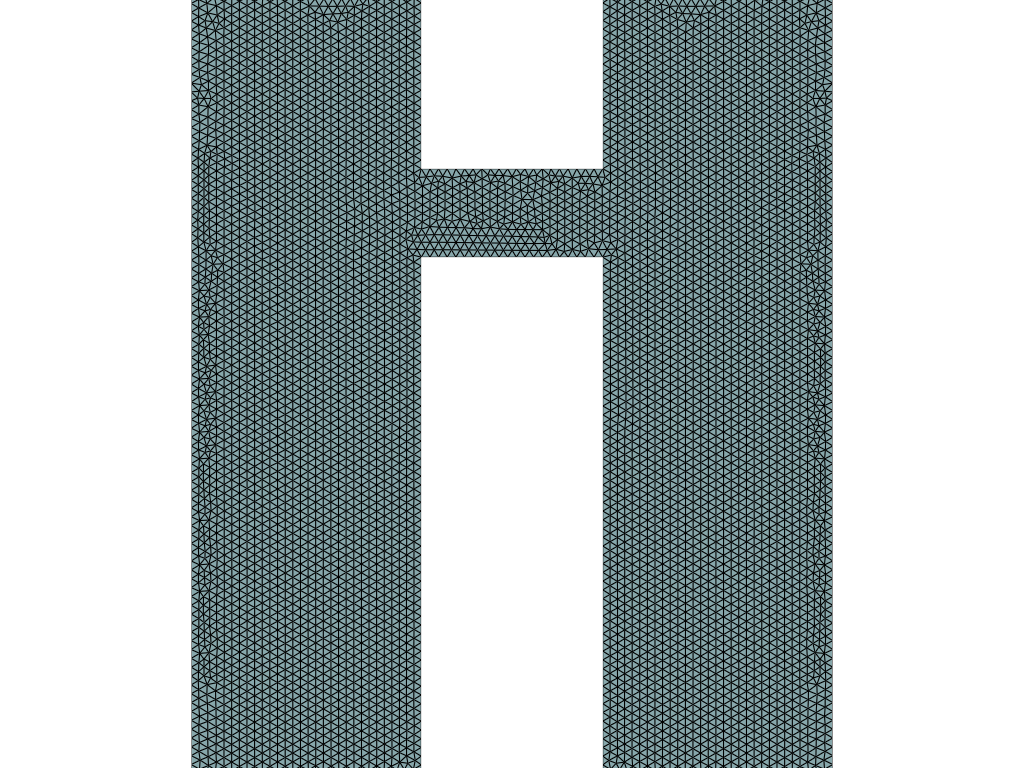

In [1]:
import gmsh
import numpy as np
import pyvista
import ufl

from mpi4py import MPI
from petsc4py import PETSc
from dolfinx import fem, io, mesh as dmesh
from dolfinx.io import gmshio
from dolfinx.plot import vtk_mesh
from dolfinx.fem.petsc import LinearProblem

# Comunicação MPI
comm = MPI.COMM_WORLD
model_rank = 0
gdim = 2

# Medidas do datasheet em metros
W_total = 19.1e-3
H_total = 18.8e-3
W_terminal = 5.2e-3
H_terminal_exposed = 6.5e-3
W_terminals_outer = 14.5e-3
thickness_z = 0.65e-3

# Medidas derivadas
H_body = H_total - H_terminal_exposed
x_gap = W_terminals_outer - 2 * W_terminal
x_left_terminal = (W_total - W_terminals_outer) / 2
x_right_terminal = x_left_terminal + W_terminal + x_gap

x_left_inner = x_left_terminal + W_terminal
x_right_inner = x_right_terminal

# Filamento simplificado
L_filament = 11.0e-3
H_filament = 2.0e-3

x_filament_center = 0.5 * (x_left_inner + x_right_inner)
x_filament_start = x_filament_center - L_filament / 2

y_filament_center = H_terminal_exposed + 0.55 * H_body
y_filament_start = y_filament_center - H_filament / 2

# Malha
mesh_size = 2.0e-4

# Tags
FUSE_DOMAIN = 1
LEFT_CONTACT = 11
RIGHT_CONTACT = 12

print(f"Largura total: {W_total*1e3:.2f} mm")
print(f"Altura total: {H_total*1e3:.2f} mm")
print(f"Largura de cada terminal: {W_terminal*1e3:.2f} mm")
print(f"Espessura fora do plano: {thickness_z*1e3:.2f} mm")

# Cria a geometria no GMSH
gmsh.initialize()
gmsh.model.add("tc06_fusivel_simplificado")

left_terminal = gmsh.model.occ.addRectangle(
    x_left_terminal, 0.0, 0.0, W_terminal, H_total
)

right_terminal = gmsh.model.occ.addRectangle(
    x_right_terminal, 0.0, 0.0, W_terminal, H_total
)

filament = gmsh.model.occ.addRectangle(
    x_filament_start, y_filament_start, 0.0, L_filament, H_filament
)

gmsh.model.occ.synchronize()

# Une terminais e filamento em um único domínio metálico
gmsh.model.occ.fuse(
    [(2, left_terminal)],
    [(2, right_terminal), (2, filament)],
    removeObject=True,
    removeTool=True
)

gmsh.model.occ.synchronize()

# Marca apenas o domínio metálico
surfaces = gmsh.model.getEntities(dim=2)
surface_tags = [tag for dim, tag in surfaces]

gmsh.model.addPhysicalGroup(2, surface_tags, FUSE_DOMAIN)
gmsh.model.setPhysicalName(2, FUSE_DOMAIN, "FuseDomain")

# Gera a malha
gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
gmsh.option.setNumber("Mesh.CharacteristicLengthMin", mesh_size / 5)
gmsh.model.mesh.generate(2)

# Converte para Dolfinx
domain, cell_tags, facet_tags = gmshio.model_to_mesh(
    gmsh.model,
    comm,
    model_rank,
    gdim=gdim
)

domain.name = "fusivel"
cell_tags.name = "cell_tags"

gmsh.finalize()

# Salva a malha
with io.XDMFFile(domain.comm, "tc06_malha_fusivel.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)

# Visualiza a malha
try:
    pyvista.start_xvfb()
except Exception:
    pass

tdim = domain.topology.dim
domain.topology.create_connectivity(tdim, tdim)

grid = pyvista.UnstructuredGrid(*vtk_mesh(domain, tdim))

plotter = pyvista.Plotter()
plotter.add_mesh(grid, show_edges=True)
plotter.view_xy()
plotter.camera.zoom(1.4)
plotter.show()

Facets contato esquerdo: 26
Facets contato direito: 26
Dofs Dirichlet direito: 27
Comprimento integrado do contato esquerdo = 5.200000e-03 m
Corrente imposta pela integral = 40.000000 A
sigma = 9.0909e+06 S/m
J_n imposto = 1.1834e+07 A/m²
Corrente nominal imposta = 40.0000 A
Corrente calculada saindo pela direita = 40.0000 A
Módulo da corrente de saída = 40.0000 A
Potencial máximo = 5.359635e-02 V
Potencial mínimo = 0.000000e+00 V


error: XDG_RUNTIME_DIR is invalid or not set in the environment.
MESA: error: ZINK: failed to choose pdev
glx: failed to create drisw screen


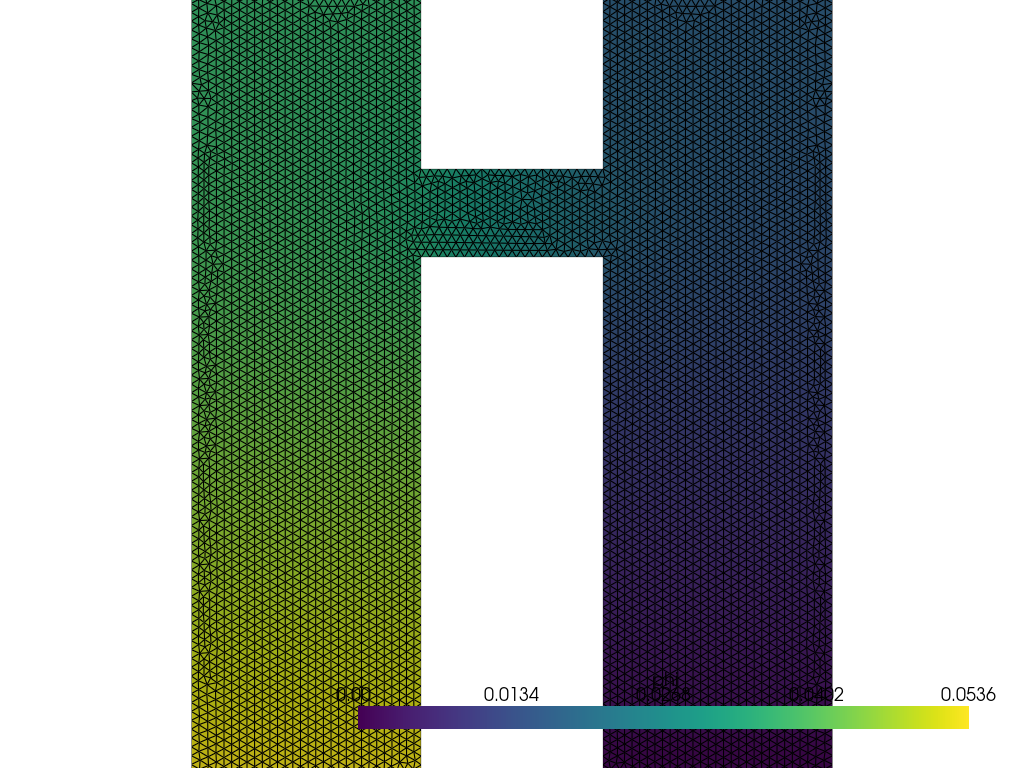

In [2]:
# Espaço de funções para o potencial elétrico
V_phi = fem.functionspace(domain, ("Lagrange", 1))

fdim = domain.topology.dim - 1
tol = 1e-6

# Contato esquerdo: entrada de corrente, condição de Neumann
left_facets = dmesh.locate_entities_boundary(
    domain,
    fdim,
    lambda x: (
        np.isclose(x[1], 0.0, atol=tol)
        & (x[0] >= x_left_terminal - tol)
        & (x[0] <= x_left_terminal + W_terminal + tol)
    )
)

# Contato direito: referência de potencial, condição de Dirichlet
right_facets = dmesh.locate_entities_boundary(
    domain,
    fdim,
    lambda x: (
        np.isclose(x[1], 0.0, atol=tol)
        & (x[0] >= x_right_terminal - tol)
        & (x[0] <= x_right_terminal + W_terminal + tol)
    )
)

right_dofs = fem.locate_dofs_geometrical(
    V_phi,
    lambda x: (
        np.isclose(x[1], 0.0, atol=tol)
        & (x[0] >= x_right_terminal - tol)
        & (x[0] <= x_right_terminal + W_terminal + tol)
    )
)

n_left = domain.comm.allreduce(len(left_facets), op=MPI.SUM)
n_right = domain.comm.allreduce(len(right_facets), op=MPI.SUM)
n_dofs_right = domain.comm.allreduce(len(right_dofs), op=MPI.SUM)

print("Facets contato esquerdo:", n_left)
print("Facets contato direito:", n_right)
print("Dofs Dirichlet direito:", n_dofs_right)

if n_left == 0:
    raise RuntimeError("Contato esquerdo não encontrado.")

if n_right == 0:
    raise RuntimeError("Contato direito não encontrado.")

if n_dofs_right == 0:
    raise RuntimeError("Dofs de Dirichlet não encontrados no contato direito.")

# Cria tags de fronteira apenas para o problema elétrico
marked_facets = np.hstack([left_facets, right_facets])

marked_values = np.hstack([
    np.full(len(left_facets), LEFT_CONTACT, dtype=np.int32),
    np.full(len(right_facets), RIGHT_CONTACT, dtype=np.int32)
])

sorted_facets = np.argsort(marked_facets)

electric_facet_tags = dmesh.meshtags(
    domain,
    fdim,
    marked_facets[sorted_facets],
    marked_values[sorted_facets]
)

# Medidas de integração
dx = ufl.Measure("dx", domain=domain)
ds_e = ufl.Measure("ds", domain=domain, subdomain_data=electric_facet_tags)
n = ufl.FacetNormal(domain)

# Propriedades elétricas do estanho
rho_e0 = 11e-8
sigma0 = 1.0 / rho_e0
sigma = fem.Constant(domain, PETSc.ScalarType(sigma0))

# Corrente nominal do fusível
I_nominal = 40.0

# Densidade de corrente normal imposta no contato esquerdo
J_n = I_nominal / (W_terminal * thickness_z)

# Verificação da corrente imposta
one = fem.Constant(domain, PETSc.ScalarType(1.0))

left_length_local = fem.assemble_scalar(
    fem.form(one * ds_e(LEFT_CONTACT))
)

left_length = domain.comm.allreduce(left_length_local, op=MPI.SUM)
I_in_check = J_n * thickness_z * left_length

print(f"Comprimento integrado do contato esquerdo = {left_length:.6e} m")
print(f"Corrente imposta pela integral = {I_in_check:.6f} A")

# Forma fraca elétrica
phi = ufl.TrialFunction(V_phi)
w = ufl.TestFunction(V_phi)

bc_right = fem.dirichletbc(
    PETSc.ScalarType(0.0),
    right_dofs,
    V_phi
)

a_phi = sigma * ufl.dot(ufl.grad(phi), ufl.grad(w)) * dx
L_phi = J_n * w * ds_e(LEFT_CONTACT)

problem_phi = LinearProblem(
    a_phi,
    L_phi,
    bcs=[bc_right],
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
)

phi_h = problem_phi.solve()
phi_h.name = "phi_V"

# Calcula a corrente de saída pelo contato direito
J_expr = -sigma * ufl.grad(phi_h)

I_out_local = fem.assemble_scalar(
    fem.form(thickness_z * ufl.dot(J_expr, n) * ds_e(RIGHT_CONTACT))
)

I_out = domain.comm.allreduce(I_out_local, op=MPI.SUM)

print(f"sigma = {sigma0:.4e} S/m")
print(f"J_n imposto = {J_n:.4e} A/m²")
print(f"Corrente nominal imposta = {I_nominal:.4f} A")
print(f"Corrente calculada saindo pela direita = {I_out:.4f} A")
print(f"Módulo da corrente de saída = {abs(I_out):.4f} A")
print(f"Potencial máximo = {np.max(phi_h.x.array):.6e} V")
print(f"Potencial mínimo = {np.min(phi_h.x.array):.6e} V")

# Salva o potencial elétrico
with io.XDMFFile(domain.comm, "tc06_potencial_eletrico.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)
    xdmf.write_function(phi_h, 0.0)

# Visualiza o potencial no notebook
topology, cell_types, geometry = vtk_mesh(V_phi)

grid_phi = pyvista.UnstructuredGrid(topology, cell_types, geometry)
grid_phi.point_data["phi"] = phi_h.x.array.real

plotter = pyvista.Plotter()
plotter.add_mesh(grid_phi, scalars="phi", show_edges=True)
plotter.view_xy()
plotter.camera.zoom(1.4)
plotter.show()

In [3]:
# Problema térmico desacoplado com fonte Joule do problema elétrico

V_T = fem.functionspace(domain, ("Lagrange", 1))
V0 = fem.functionspace(domain, ("DG", 0))

f_joule_h = fem.Function(V0)
f_joule_h.name = "f_joule_W_m3"

f_joule_expr = fem.Expression(
    sigma * ufl.dot(ufl.grad(phi_h), ufl.grad(phi_h)),
    V0.element.interpolation_points()
)

f_joule_h.interpolate(f_joule_expr)
f_joule_h.x.scatter_forward()

P_joule_local = fem.assemble_scalar(fem.form(thickness_z * f_joule_h * dx))
P_joule = domain.comm.allreduce(P_joule_local, op=MPI.SUM)

P_elec_local = fem.assemble_scalar(
    fem.form(thickness_z * J_n * phi_h * ds_e(LEFT_CONTACT))
)
P_elec = domain.comm.allreduce(P_elec_local, op=MPI.SUM)

rho_m = 7310.0
cp_m = 228.0
k_m = 66.8

T_inf = 298.15
T_melt = 505.08
h_conv = 10.0
usar_conveccao_faces = True

print("\n=== Fonte Joule e parâmetros térmicos ===")
print(f"Potência Joule integrada = {P_joule:.6e} W")
print(f"Potência elétrica pela fronteira = {P_elec:.6e} W")
print(f"T ambiente = {T_inf:.2f} K = {T_inf - 273.15:.2f} °C")
print(f"T fusão estanho = {T_melt:.2f} K = {T_melt - 273.15:.2f} °C")

# Marca toda a fronteira externa para convecção
THERMAL_BOUNDARY = 21

all_boundary_facets = dmesh.locate_entities_boundary(
    domain,
    fdim,
    lambda x: np.full(x.shape[1], True)
)

thermal_values = np.full(
    len(all_boundary_facets),
    THERMAL_BOUNDARY,
    dtype=np.int32
)

sorted_thermal_facets = np.argsort(all_boundary_facets)

thermal_facet_tags = dmesh.meshtags(
    domain,
    fdim,
    all_boundary_facets[sorted_thermal_facets],
    thermal_values[sorted_thermal_facets]
)

ds_T = ufl.Measure(
    "ds",
    domain=domain,
    subdomain_data=thermal_facet_tags
)

n_thermal = domain.comm.allreduce(len(all_boundary_facets), op=MPI.SUM)
print(f"Facets com convecção térmica = {n_thermal}")

# Integração temporal por Euler implícito
dt = 0.05
t_final = 5.0
num_steps = int(t_final / dt)

T_old = fem.Function(V_T)
T_old.name = "T_K"
T_old.x.array[:] = T_inf
T_old.x.scatter_forward()

T_h = fem.Function(V_T)
T_h.name = "T_K"

T = ufl.TrialFunction(V_T)
v = ufl.TestFunction(V_T)

a_T = (
    rho_m * cp_m * thickness_z / dt * T * v * dx
    + k_m * thickness_z * ufl.dot(ufl.grad(T), ufl.grad(v)) * dx
    + h_conv * thickness_z * T * v * ds_T(THERMAL_BOUNDARY)
)

L_T = (
    rho_m * cp_m * thickness_z / dt * T_old * v * dx
    + thickness_z * f_joule_h * v * dx
    + h_conv * thickness_z * T_inf * v * ds_T(THERMAL_BOUNDARY)
)

if usar_conveccao_faces:
    a_T += 2.0 * h_conv * T * v * dx
    L_T += 2.0 * h_conv * T_inf * v * dx

problem_T = LinearProblem(
    a_T,
    L_T,
    u=T_h,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
)

print("\n=== Simulação térmica desacoplada ===")
print(f"dt = {dt:.4f} s")
print(f"Tempo final = {t_final:.4f} s")
print(f"Número de passos = {num_steps}")

print_every = max(1, int(1.0 / dt))

with io.XDMFFile(domain.comm, "tc06_temperatura_desacoplado.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)
    xdmf.write_function(T_old, 0.0)

    for step in range(1, num_steps + 1):
        t = step * dt

        problem_T.solve()
        T_h.x.scatter_forward()

        if step == 1 or step % print_every == 0 or step == num_steps:
            T_max = domain.comm.allreduce(np.max(T_h.x.array), op=MPI.MAX)
            print(f"t = {t:6.2f} s | T_max = {T_max:.3f} K = {T_max - 273.15:.3f} °C")

        xdmf.write_function(T_h, t)

        T_old.x.array[:] = T_h.x.array
        T_old.x.scatter_forward()

with io.XDMFFile(domain.comm, "tc06_fonte_joule.xdmf", "w") as xdmf:
    xdmf.write_mesh(domain)
    xdmf.write_function(f_joule_h, 0.0)

T_min_final = domain.comm.allreduce(np.min(T_h.x.array), op=MPI.MIN)
T_max_final = domain.comm.allreduce(np.max(T_h.x.array), op=MPI.MAX)

print("\n=== Resultado final desacoplado ===")
print(f"T mínima final = {T_min_final:.3f} K = {T_min_final - 273.15:.3f} °C")
print(f"T máxima final = {T_max_final:.3f} K = {T_max_final - 273.15:.3f} °C")
print(f"Temperatura de fusão do estanho = {T_melt:.3f} K = {T_melt - 273.15:.3f} °C")

if T_max_final >= T_melt:
    print("Resultado: a temperatura máxima ultrapassou a fusão do estanho.")
else:
    print("Resultado: a temperatura máxima não atingiu a fusão do estanho.")


=== Fonte Joule e parâmetros térmicos ===
Potência Joule integrada = 2.143790e+00 W
Potência elétrica pela fronteira = 2.143790e+00 W
T ambiente = 298.15 K = 25.00 °C
T fusão estanho = 505.08 K = 231.93 °C
Facets com convecção térmica = 504

=== Simulação térmica desacoplada ===
dt = 0.0500 s
Tempo final = 5.0000 s
Número de passos = 100
t =   0.05 s | T_max = 300.644 K = 27.494 °C
t =   1.00 s | T_max = 314.286 K = 41.136 °C
t =   2.00 s | T_max = 323.643 K = 50.493 °C
t =   3.00 s | T_max = 332.824 K = 59.674 °C
t =   4.00 s | T_max = 341.823 K = 68.673 °C
t =   5.00 s | T_max = 350.637 K = 77.487 °C

=== Resultado final desacoplado ===
T mínima final = 341.344 K = 68.194 °C
T máxima final = 350.637 K = 77.487 °C
Temperatura de fusão do estanho = 505.080 K = 231.930 °C
Resultado: a temperatura máxima não atingiu a fusão do estanho.


In [4]:
# Problema termoelétrico acoplado com atualização de sigma(T)

T_max_desacoplado = T_max_final

V_phi_c = V_phi
V_T_c = fem.functionspace(domain, ("Lagrange", 1))
V0_c = fem.functionspace(domain, ("DG", 0))

rho_e0 = 11e-8
sigma0 = 1.0 / rho_e0
alpha_rho = 4.5e-3
T_ref = 293.15

rho_m = 7310.0
cp_m = 228.0
k_m = 66.8

T_inf = 298.15
T_melt = 505.08
h_conv = 10.0

dt = 0.05
t_final = 5.0
num_steps = int(t_final / dt)

sigma_T = fem.Function(V0_c)
sigma_T.name = "sigma_T"

f_joule_c = fem.Function(V0_c)
f_joule_c.name = "f_joule_acoplado_W_m3"

phi_c = fem.Function(V_phi_c)
phi_c.name = "phi_acoplado_V"

T_old_c = fem.Function(V_T_c)
T_old_c.name = "T_old_acoplado_K"
T_old_c.x.array[:] = T_inf
T_old_c.x.scatter_forward()

T_c = fem.Function(V_T_c)
T_c.name = "T_acoplado_K"

def atualizar_sigma(T_func):
    sigma_expr = fem.Expression(
        sigma0 / (1.0 + alpha_rho * (T_func - T_ref)),
        V0_c.element.interpolation_points()
    )
    sigma_T.interpolate(sigma_expr)
    sigma_T.x.scatter_forward()

atualizar_sigma(T_old_c)

phi_trial = ufl.TrialFunction(V_phi_c)
w_phi = ufl.TestFunction(V_phi_c)

a_phi_c = sigma_T * ufl.dot(ufl.grad(phi_trial), ufl.grad(w_phi)) * dx
L_phi_c = J_n * w_phi * ds_e(LEFT_CONTACT)

problem_phi_c = LinearProblem(
    a_phi_c,
    L_phi_c,
    u=phi_c,
    bcs=[bc_right],
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
)

T_trial = ufl.TrialFunction(V_T_c)
v_T = ufl.TestFunction(V_T_c)

a_T_c = (
    rho_m * cp_m * thickness_z / dt * T_trial * v_T * dx
    + k_m * thickness_z * ufl.dot(ufl.grad(T_trial), ufl.grad(v_T)) * dx
    + h_conv * thickness_z * T_trial * v_T * ds_T(THERMAL_BOUNDARY)
    + 2.0 * h_conv * T_trial * v_T * dx
)

L_T_c = (
    rho_m * cp_m * thickness_z / dt * T_old_c * v_T * dx
    + thickness_z * f_joule_c * v_T * dx
    + h_conv * thickness_z * T_inf * v_T * ds_T(THERMAL_BOUNDARY)
    + 2.0 * h_conv * T_inf * v_T * dx
)

problem_T_c = LinearProblem(
    a_T_c,
    L_T_c,
    u=T_c,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
)

print("\n=== Simulação termoelétrica acoplada ===")
print(f"T ambiente = {T_inf:.2f} K = {T_inf - 273.15:.2f} °C")
print(f"alpha resistividade = {alpha_rho:.4e} 1/K")
print(f"dt = {dt:.4f} s | tempo final = {t_final:.4f} s")

print_every = max(1, int(1.0 / dt))

with io.XDMFFile(domain.comm, "tc06_temperatura_acoplado.xdmf", "w") as xdmf_T, \
     io.XDMFFile(domain.comm, "tc06_potencial_acoplado.xdmf", "w") as xdmf_phi, \
     io.XDMFFile(domain.comm, "tc06_fonte_joule_acoplado.xdmf", "w") as xdmf_f:

    xdmf_T.write_mesh(domain)
    xdmf_phi.write_mesh(domain)
    xdmf_f.write_mesh(domain)

    xdmf_T.write_function(T_old_c, 0.0)

    for step in range(1, num_steps + 1):
        t = step * dt

        atualizar_sigma(T_old_c)

        problem_phi_c.solve()
        phi_c.x.scatter_forward()

        f_expr = fem.Expression(
            sigma_T * ufl.dot(ufl.grad(phi_c), ufl.grad(phi_c)),
            V0_c.element.interpolation_points()
        )

        f_joule_c.interpolate(f_expr)
        f_joule_c.x.scatter_forward()

        problem_T_c.solve()
        T_c.x.scatter_forward()

        if step == 1 or step % print_every == 0 or step == num_steps:
            T_max = domain.comm.allreduce(np.max(T_c.x.array), op=MPI.MAX)
            sigma_min = domain.comm.allreduce(np.min(sigma_T.x.array), op=MPI.MIN)

            P_joule_local = fem.assemble_scalar(
                fem.form(thickness_z * f_joule_c * dx)
            )
            P_joule = domain.comm.allreduce(P_joule_local, op=MPI.SUM)

            print(
                f"t = {t:6.2f} s | "
                f"T_max = {T_max:.3f} K = {T_max - 273.15:.3f} °C | "
                f"sigma_min = {sigma_min:.4e} S/m | "
                f"P = {P_joule:.6e} W"
            )

        xdmf_T.write_function(T_c, t)
        xdmf_phi.write_function(phi_c, t)
        xdmf_f.write_function(f_joule_c, t)

        T_old_c.x.array[:] = T_c.x.array
        T_old_c.x.scatter_forward()

T_min_acoplado = domain.comm.allreduce(np.min(T_c.x.array), op=MPI.MIN)
T_max_acoplado = domain.comm.allreduce(np.max(T_c.x.array), op=MPI.MAX)
sigma_min_final = domain.comm.allreduce(np.min(sigma_T.x.array), op=MPI.MIN)
sigma_max_final = domain.comm.allreduce(np.max(sigma_T.x.array), op=MPI.MAX)

print("\n=== Resultado final acoplado ===")
print(f"T mínima final = {T_min_acoplado:.3f} K = {T_min_acoplado - 273.15:.3f} °C")
print(f"T máxima final = {T_max_acoplado:.3f} K = {T_max_acoplado - 273.15:.3f} °C")
print(f"T máxima desacoplada = {T_max_desacoplado:.3f} K = {T_max_desacoplado - 273.15:.3f} °C")
print(f"Diferença acoplado - desacoplado = {T_max_acoplado - T_max_desacoplado:.3f} K")
print(f"sigma mínima final = {sigma_min_final:.6e} S/m")
print(f"sigma máxima final = {sigma_max_final:.6e} S/m")
print(f"Temperatura de fusão do estanho = {T_melt:.3f} K = {T_melt - 273.15:.3f} °C")

if T_max_acoplado >= T_melt:
    print("Resultado: a temperatura máxima ultrapassou a fusão do estanho.")
else:
    print("Resultado: a temperatura máxima não atingiu a fusão do estanho.")


=== Simulação termoelétrica acoplada ===
T ambiente = 298.15 K = 25.00 °C
alpha resistividade = 4.5000e-03 1/K
dt = 0.0500 s | tempo final = 5.0000 s
t =   0.05 s | T_max = 300.700 K = 27.550 °C | sigma_min = 8.8909e+06 S/m | P = 2.192025e+00 W
t =   1.00 s | T_max = 315.391 K = 42.241 °C | sigma_min = 8.2818e+06 S/m | P = 2.303823e+00 W
t =   2.00 s | T_max = 326.019 K = 52.869 °C | sigma_min = 7.9363e+06 S/m | P = 2.404475e+00 W
t =   3.00 s | T_max = 336.902 K = 63.752 °C | sigma_min = 7.6113e+06 S/m | P = 2.507326e+00 W
t =   4.00 s | T_max = 348.044 K = 74.894 °C | sigma_min = 7.3051e+06 S/m | P = 2.612528e+00 W
t =   5.00 s | T_max = 359.444 K = 86.294 °C | sigma_min = 7.0162e+06 S/m | P = 2.720138e+00 W

=== Resultado final acoplado ===
T mínima final = 347.592 K = 74.442 °C
T máxima final = 359.444 K = 86.294 °C
T máxima desacoplada = 350.637 K = 77.487 °C
Diferença acoplado - desacoplado = 8.808 K
sigma mínima final = 7.016151e+06 S/m
sigma máxima final = 7.316529e+06 S/m
Tem


=== Varredura de corrente acoplada ===
dt = 0.050 s | tempo máximo = 20.000 s
Temperatura de fusão = 505.08 K = 231.93 °C
I =   40.0 A | tempo fusão =  16.150 s | T_max =  505.708 K (232.558 °C) | P = 4.1005e+00 W | fundiu
I =   60.0 A | tempo fusão =   6.150 s | T_max =  506.013 K (232.863 °C) | P = 8.9596e+00 W | fundiu
I =   80.0 A | tempo fusão =   3.000 s | T_max =  505.185 K (232.035 °C) | P = 1.5218e+01 W | fundiu
I =  100.0 A | tempo fusão =   1.650 s | T_max =  510.238 K (237.088 °C) | P = 2.2700e+01 W | fundiu
I =  120.0 A | tempo fusão =   0.900 s | T_max =  508.372 K (235.222 °C) | P = 3.0381e+01 W | fundiu

=== Tabela resumo ===
I_A, tempo_fusao_s, T_max_K, T_max_C, P_final_W, fundiu
40.0, 16.150000000000002, 505.708, 232.558, 4.100489e+00, True
60.0, 6.15, 506.013, 232.863, 8.959573e+00, True
80.0, 3.0, 505.185, 232.035, 1.521763e+01, True
100.0, 1.6500000000000001, 510.238, 237.088, 2.269994e+01, True
120.0, 0.9, 508.372, 235.222, 3.038131e+01, True


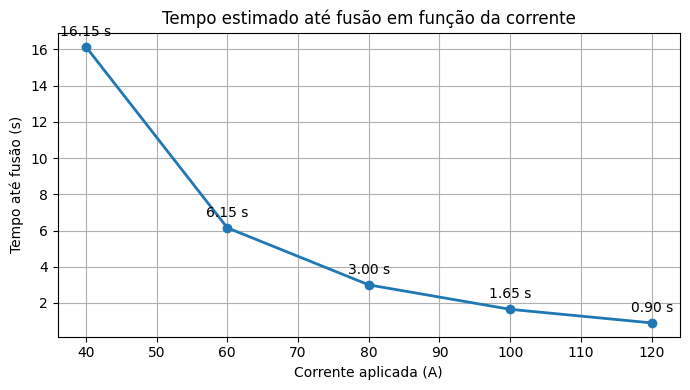

In [5]:
# Varredura de corrente para estimar tempo até fusão

correntes_teste = [40.0, 60.0, 80.0, 100.0, 120.0]

dt_varredura = 0.05
t_final_varredura = 20.0
num_steps_varredura = int(t_final_varredura / dt_varredura)

V_T_s = fem.functionspace(domain, ("Lagrange", 1))
V0_s = fem.functionspace(domain, ("DG", 0))

rho_e0 = 11e-8
sigma0 = 1.0 / rho_e0
alpha_rho = 4.5e-3
T_ref = 293.15

rho_m = 7310.0
cp_m = 228.0
k_m = 66.8

T_inf = 298.15
T_melt = 505.08
h_conv = 10.0

sigma_s = fem.Function(V0_s)
f_joule_s = fem.Function(V0_s)
phi_s = fem.Function(V_phi)
T_old_s = fem.Function(V_T_s)
T_s = fem.Function(V_T_s)

Jn_const = fem.Constant(domain, PETSc.ScalarType(0.0))

def atualizar_sigma_varredura(T_func):
    sigma_expr = fem.Expression(
        sigma0 / (1.0 + alpha_rho * (T_func - T_ref)),
        V0_s.element.interpolation_points()
    )
    sigma_s.interpolate(sigma_expr)
    sigma_s.x.scatter_forward()

phi_trial_s = ufl.TrialFunction(V_phi)
w_phi_s = ufl.TestFunction(V_phi)

a_phi_s = sigma_s * ufl.dot(ufl.grad(phi_trial_s), ufl.grad(w_phi_s)) * dx
L_phi_s = Jn_const * w_phi_s * ds_e(LEFT_CONTACT)

problem_phi_s = LinearProblem(
    a_phi_s,
    L_phi_s,
    u=phi_s,
    bcs=[bc_right],
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
)

T_trial_s = ufl.TrialFunction(V_T_s)
v_T_s = ufl.TestFunction(V_T_s)

a_T_s = (
    rho_m * cp_m * thickness_z / dt_varredura * T_trial_s * v_T_s * dx
    + k_m * thickness_z * ufl.dot(ufl.grad(T_trial_s), ufl.grad(v_T_s)) * dx
    + h_conv * thickness_z * T_trial_s * v_T_s * ds_T(THERMAL_BOUNDARY)
    + 2.0 * h_conv * T_trial_s * v_T_s * dx
)

L_T_s = (
    rho_m * cp_m * thickness_z / dt_varredura * T_old_s * v_T_s * dx
    + thickness_z * f_joule_s * v_T_s * dx
    + h_conv * thickness_z * T_inf * v_T_s * ds_T(THERMAL_BOUNDARY)
    + 2.0 * h_conv * T_inf * v_T_s * dx
)

problem_T_s = LinearProblem(
    a_T_s,
    L_T_s,
    u=T_s,
    petsc_options={"ksp_type": "preonly", "pc_type": "lu"}
)

resultados_varredura = []

print("\n=== Varredura de corrente acoplada ===")
print(f"dt = {dt_varredura:.3f} s | tempo máximo = {t_final_varredura:.3f} s")
print(f"Temperatura de fusão = {T_melt:.2f} K = {T_melt - 273.15:.2f} °C")

for I_teste in correntes_teste:
    Jn_const.value = PETSc.ScalarType(I_teste / (W_terminal * thickness_z))

    T_old_s.x.array[:] = T_inf
    T_old_s.x.scatter_forward()

    tempo_fusao = None
    T_max_atual = T_inf
    P_joule_atual = 0.0

    for step in range(1, num_steps_varredura + 1):
        t = step * dt_varredura

        atualizar_sigma_varredura(T_old_s)

        problem_phi_s.solve()
        phi_s.x.scatter_forward()

        f_expr_s = fem.Expression(
            sigma_s * ufl.dot(ufl.grad(phi_s), ufl.grad(phi_s)),
            V0_s.element.interpolation_points()
        )

        f_joule_s.interpolate(f_expr_s)
        f_joule_s.x.scatter_forward()

        problem_T_s.solve()
        T_s.x.scatter_forward()

        T_max_atual = domain.comm.allreduce(np.max(T_s.x.array), op=MPI.MAX)

        if T_max_atual >= T_melt:
            tempo_fusao = t
            break

        T_old_s.x.array[:] = T_s.x.array
        T_old_s.x.scatter_forward()

    P_joule_local = fem.assemble_scalar(fem.form(thickness_z * f_joule_s * dx))
    P_joule_atual = domain.comm.allreduce(P_joule_local, op=MPI.SUM)

    fundiu = tempo_fusao is not None

    resultados_varredura.append([
        I_teste,
        tempo_fusao if fundiu else np.nan,
        T_max_atual,
        T_max_atual - 273.15,
        P_joule_atual,
        fundiu
    ])

    status = "fundiu" if fundiu else "não fundiu"
    tempo_txt = f"{tempo_fusao:.3f} s" if fundiu else f">{t_final_varredura:.3f} s"

    print(
        f"I = {I_teste:6.1f} A | "
        f"tempo fusão = {tempo_txt:>9} | "
        f"T_max = {T_max_atual:8.3f} K ({T_max_atual - 273.15:7.3f} °C) | "
        f"P = {P_joule_atual:.4e} W | "
        f"{status}"
    )

print("\n=== Tabela resumo ===")
print("I_A, tempo_fusao_s, T_max_K, T_max_C, P_final_W, fundiu")

for linha in resultados_varredura:
    print(
        f"{linha[0]:.1f}, "
        f"{linha[1] if not np.isnan(linha[1]) else 'nan'}, "
        f"{linha[2]:.3f}, "
        f"{linha[3]:.3f}, "
        f"{linha[4]:.6e}, "
        f"{linha[5]}"
    )

# Gráfico corrente versus tempo de fusão
import matplotlib.pyplot as plt

correntes_plot = []
tempos_plot = []

for linha in resultados_varredura:
    if linha[5]:
        correntes_plot.append(linha[0])
        tempos_plot.append(linha[1])

plt.figure(figsize=(7, 4))
plt.plot(correntes_plot, tempos_plot, marker="o", linewidth=2)

plt.xlabel("Corrente aplicada (A)")
plt.ylabel("Tempo até fusão (s)")
plt.title("Tempo estimado até fusão em função da corrente")
plt.grid(True)

for I, tempo in zip(correntes_plot, tempos_plot):
    plt.annotate(
        f"{tempo:.2f} s",
        (I, tempo),
        textcoords="offset points",
        xytext=(0, 8),
        ha="center"
    )

plt.tight_layout()
plt.show()